# (25) deep dec — tiny imgnet

**Motivation**: host = ```chewie```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('ImageNet32', model_type, 'ngd|deep')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 1 # 1/8 * t_train

cfg_vae['latent_channels'] = 256
cfg_vae['latent_pixels'] = 8

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

204976

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  661.0 K   |
|     ———     |    ———     |
|    layer    |  661.0 K   |
+-------------+------------+

poisson_ImageNet32_t-16_b-1_kms-(256,8,1)_<ngd|deep>
b100-ep16-lr(0.0002)_temp(0.05)_gr(4000)_(2025_07_27,09:00)

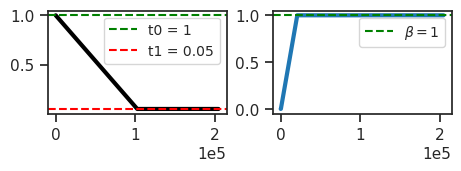

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}") # \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(256, 8, 8), input_sz=(3, 32, 32), temp=1)

In [8]:
tr.model.layer.u_init[0].shape, tr.model.layer.log_bias.shape

(torch.Size([1, 256, 1, 1]), torch.Size([1, 256, 1, 1]))

In [9]:
tr.model.cfg.set_clamp_val('u', 5.0)
tr.model.cfg.set_clamp_val('du', 5.0)

tr.model.cfg.clamp_vals

{'u': (5.0,), 'du': (5.0,), 'dec': 3.45}

In [10]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -2, 't_train': 16, 'kl_beta': 1.0, 'latent_channels': 256, 
'latent_pixels': 8, 'latent_stride': 1, 'enc_type': 'ngd', 'dec_type': 'deep', 'recon_mode': 'mse', 'dataset': 
'ImageNet32', 'dataset_name': 'ImageNet32', 'feeder': 'stationary', 'feeder_cfg': {}, 'input_sz': (3, 32, 32), 
'latent_sz': (256, 8, 8), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (5.0,), 'du': (5.0,), 
'dec': 3.45}, 'optim_sigma': False, 'stochastic': True, 'fit_prior': True, 'seed': 0, 'track_stats': False, 
'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/poisson_ImageNet32_t-16_b-1_kms-(256,8,1)_<ngd|deep>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_ImageNet32_t-16_b-1_kms-(256,8,1)_<ngd|deep>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}

{'lr': 0.0002, 'epochs': 16, 'batch_size': 100, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 15.92, 'eta_min': 1e-06}, 'ema_rate': None, 'grad_clip': 
4000, 'chkpt_freq': 1, 'eval_freq': 1, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [11]:
tr.train('expand=1_no-se')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 16, avg loss: 102.428: 100%|███████| 16/16 [29:32:58<00:00, 6648.63s/it]


100%|███████████████████████████████████| 5/5 [00:37<00:00,  7.58s/it]


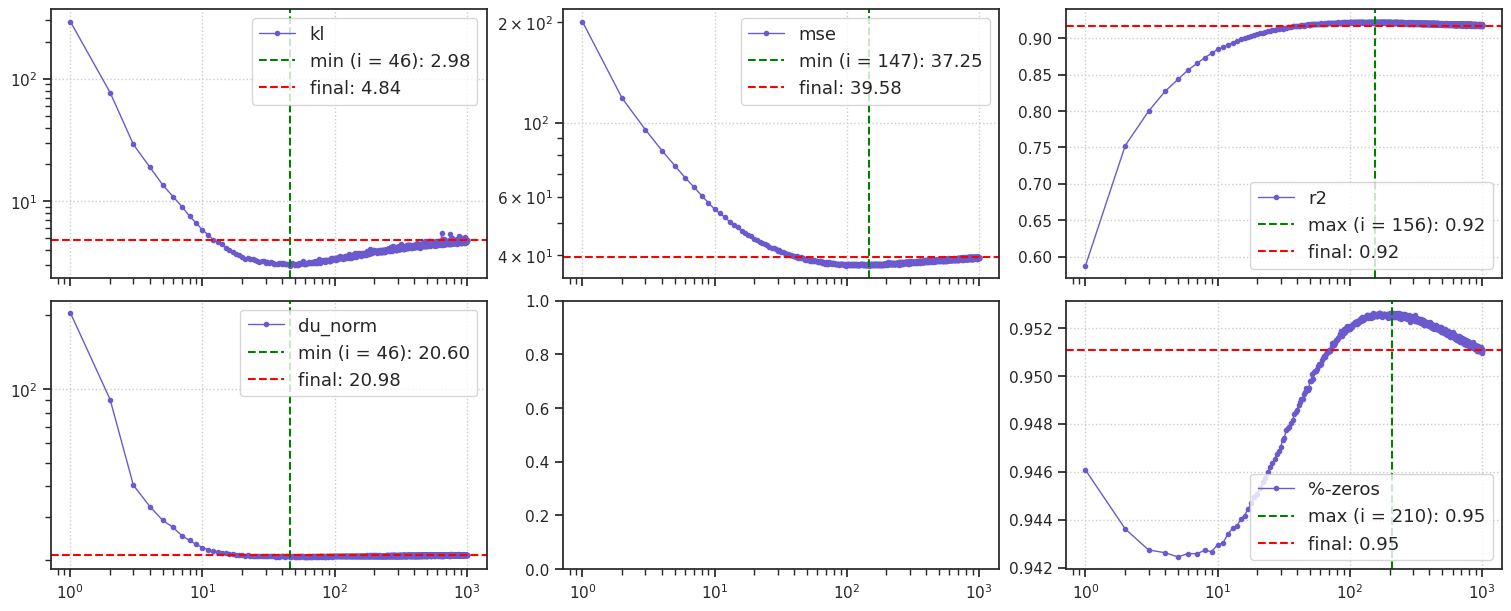

CPU times: user 49 s, sys: 8.78 s, total: 57.8 s
Wall time: 57.8 s


In [12]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='slateblue')

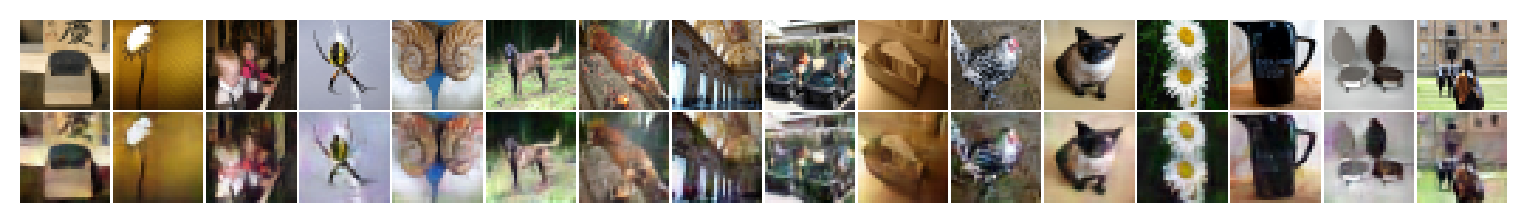

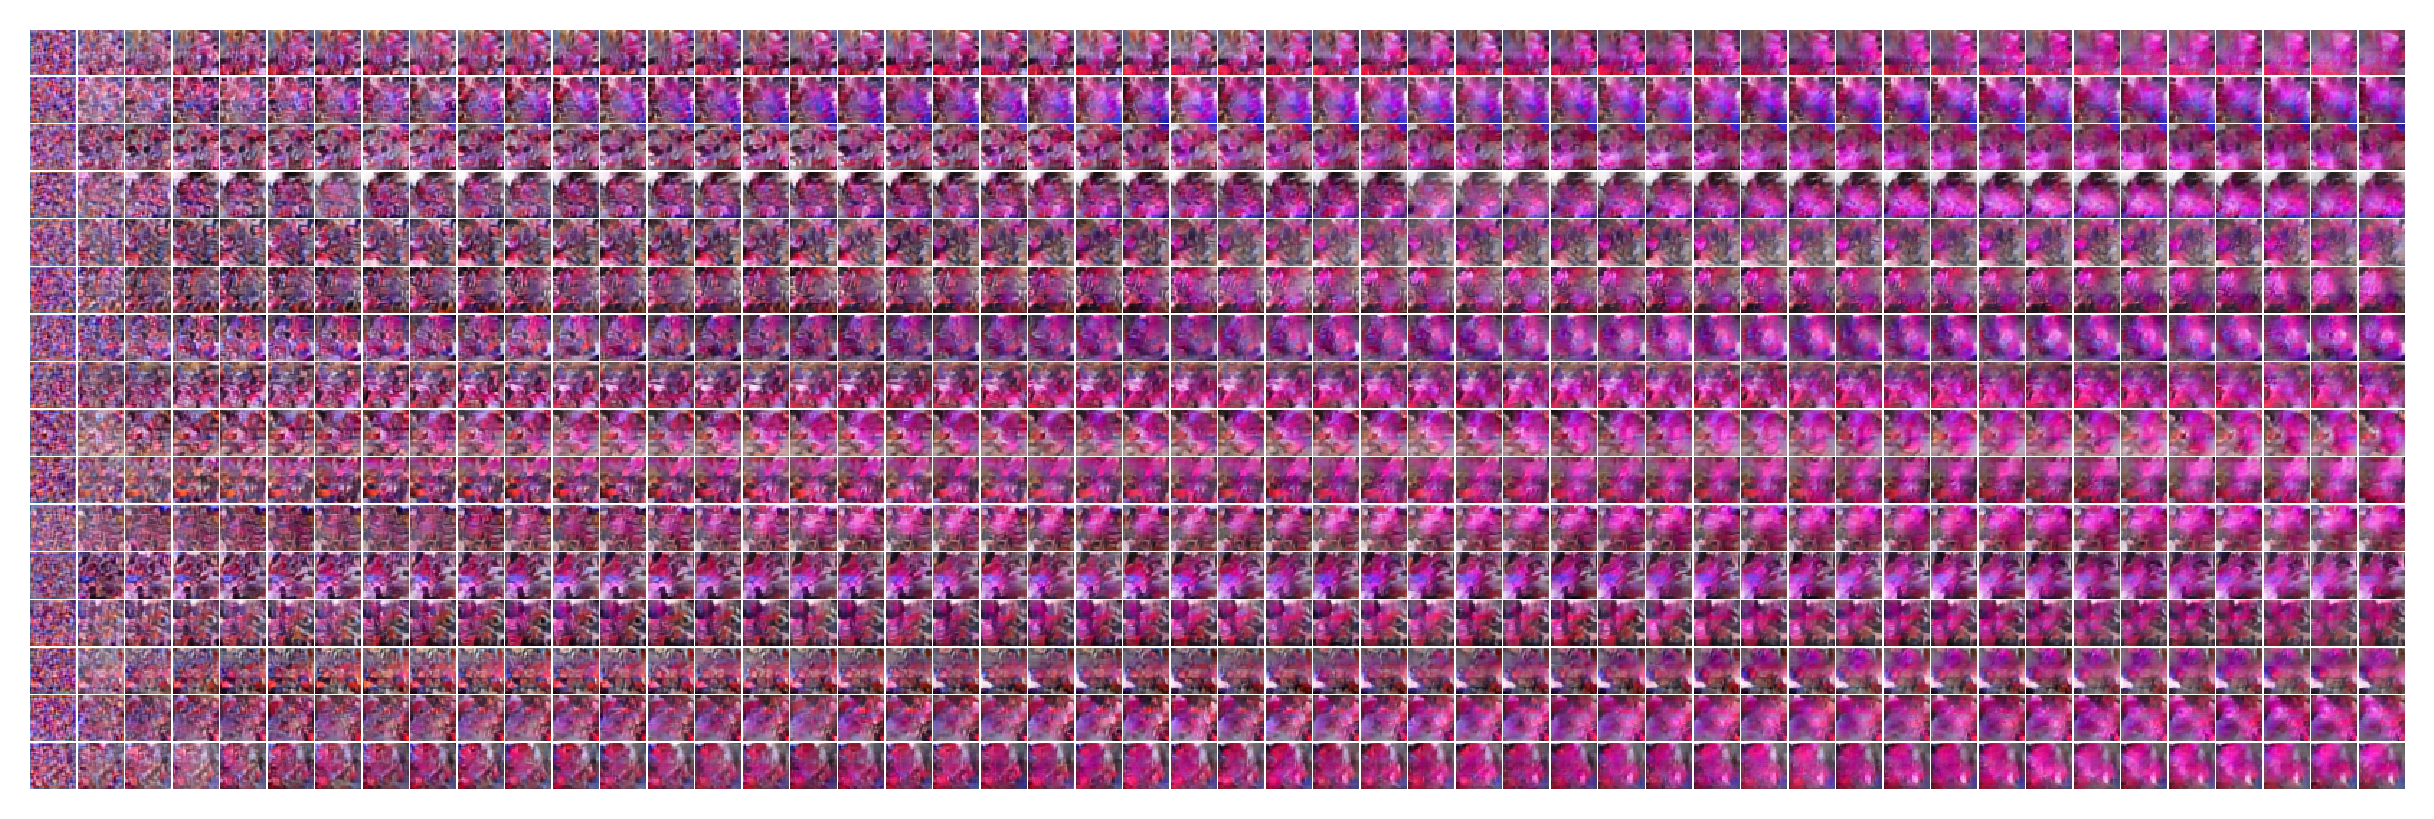

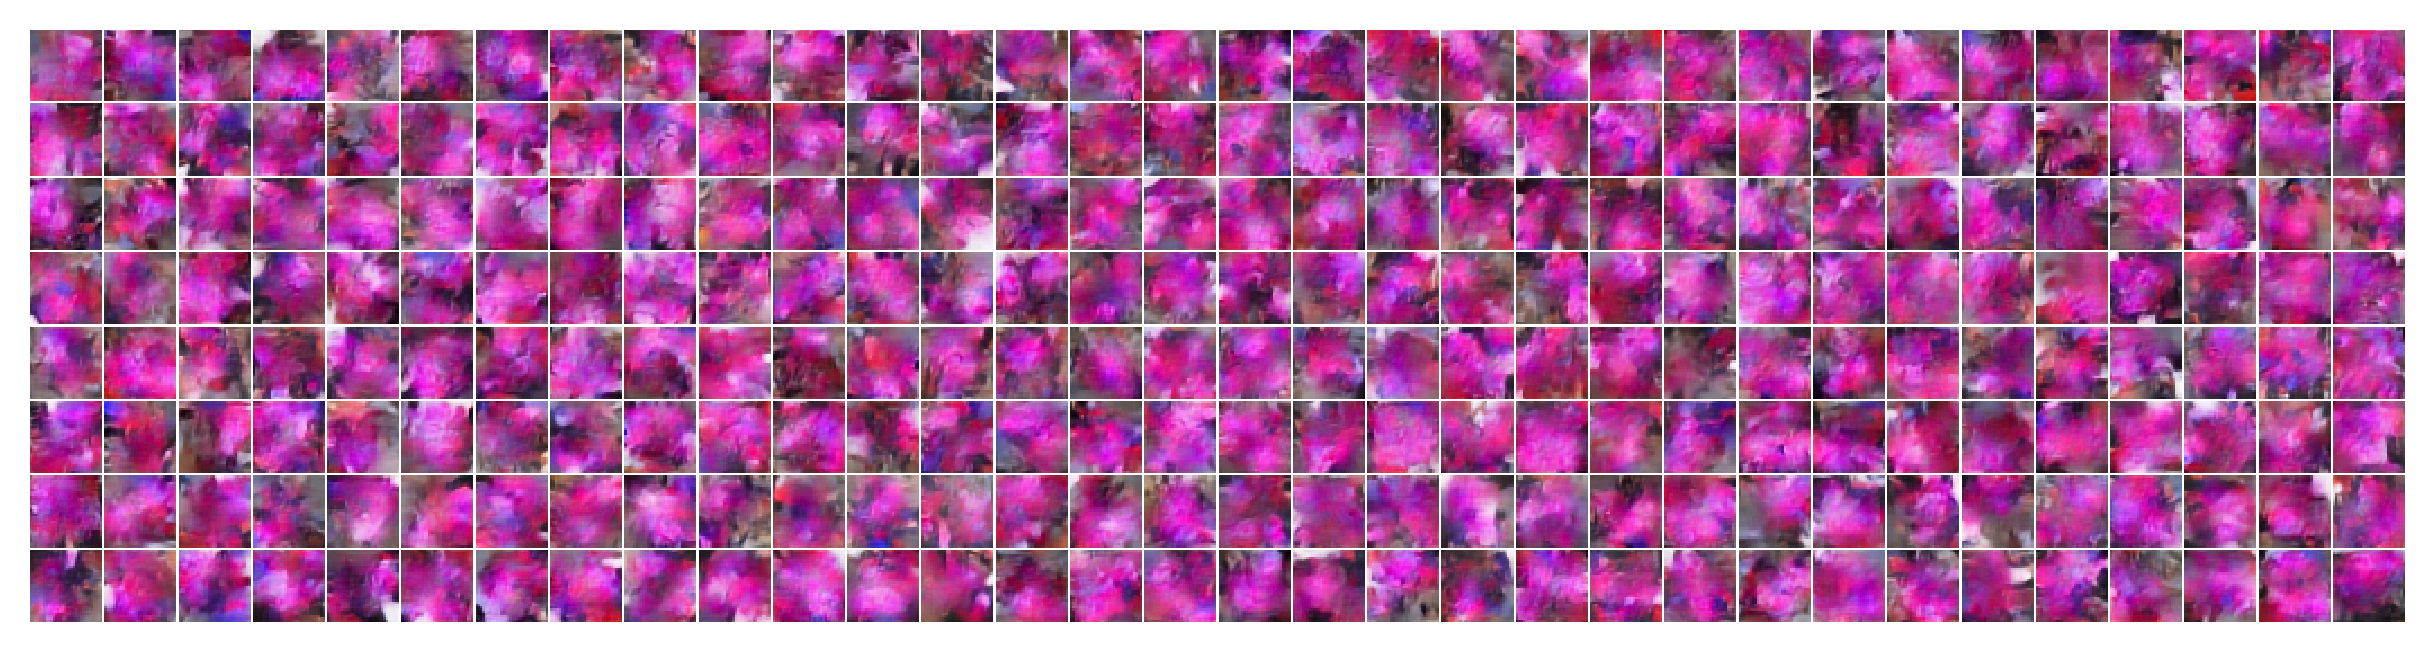

In [13]:
tr.show_recon();
tr.show_samples();

In [ ]:
%%time

kws = dict(
    t_total=10000,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='slateblue')

100%|███████████████████████████████████| 5/5 [07:10<00:00, 86.20s/it]


In [14]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)
bias.shape

(256,)

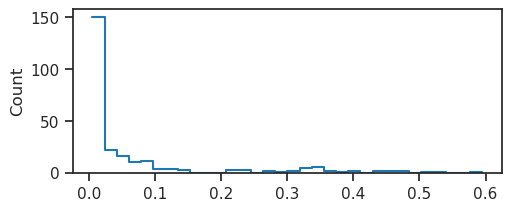

In [15]:
fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

In [16]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u0.shape

(256,)

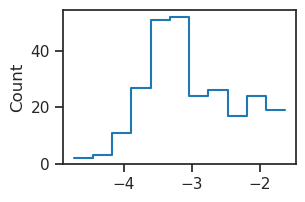

In [17]:
histplot(u0.ravel())
plt.show()

In [18]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.14394778, pvalue=0.02122798444831208)

In [19]:
tr.model.layer.dec

Sequential(
  (0): Conv2D(
    (_layer): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), padding=valid)
  )
  (1): Cell(
    (skip): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2D(
        (_layer): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (ops): ModuleList(
      (0): ConvLayer(
        (upsample): Upsample(scale_factor=2.0, mode='nearest')
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
  )
  (2): Cell(
    (skip): Identity()
    (ops): ModuleList(
      (0): ConvLayer(
        (act_fn): SiLU()
        (conv): Conv2D(
          (_layer): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
  )
  (3): Cell(
    (skip): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2D(
        (_layer): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 

In [12]:
# a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']